# Student Productivity Dataset EDA
This notebook downloads the dataset and performs Exploratory Data Analysis.

In [15]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("velvetcrystal/student-productivity-dataset")
print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print("Successfully loaded data into pandas DataFrame!")
else:
    print("No CSV files found in the dataset path.")

Matplotlib is building the font cache; this may take a moment.


Path to dataset files: /Users/mac/.cache/kagglehub/datasets/velvetcrystal/student-productivity-dataset/versions/1
Successfully loaded data into pandas DataFrame!


## 1. Data Overview
Let's look at the shape of the dataset and the first few rows.

In [16]:
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (10000, 20)


,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium


## 2. Basic Information & Missing Values

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Student_ID                        10000 non-null  int64  
 1   Age                               9845 non-null   float64
 2   Gender                            9881 non-null   object 
 3   Study_Hours_Per_Day               9835 non-null   float64
 4   Sleep_Hours_Per_Night             9894 non-null   float64
 5   Screen_Time_Hours                 9868 non-null   float64
 6   Social_Media_Hours                9920 non-null   float64
 7   Attendance_Percentage             9878 non-null   float64
 8   Assignments_Completed             9882 non-null   float64
 9   Class_Participation_Score         9815 non-null   float64
 10  Physical_Activity_Hours_Per_Week  9863 non-null   float64
 11  Stress_Level                      9846 non-null   float64
 12  Motiv

In [18]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Student_ID                            0
Age                                 155
Gender                              119
Study_Hours_Per_Day                 165
Sleep_Hours_Per_Night               106
Screen_Time_Hours                   132
Social_Media_Hours                   80
Attendance_Percentage               122
Assignments_Completed               118
Class_Participation_Score           185
Physical_Activity_Hours_Per_Week    137
Stress_Level                        154
Motivation_Level                    175
Internet_Quality                    149
Part_Time_Job                       126
Extracurricular_Involvement         178
AI_Tool_Usage_Hours_Per_Week        140
Previous_Semester_GPA               161
Productivity_Score                    0
Performance_Category                  0
dtype: int64


## 3. Summary Statistics

In [19]:
display(df.describe())

,Student_ID,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score
count,10000.00000,9845.000000,9835.000000,9894.000000,9868.000000,9920.000000,9878.000000,9882.000000,9815.000000,9863.000000,9846.000000,9825.000000,9822.000000,9860.000000,9839.000000,10000.000000
mean,5000.50000,20.134891,4.219583,6.976602,6.047862,3.032107,79.817301,74.251872,5.991218,3.200862,5.542840,5.957924,4.050204,5.544726,6.489753,54.607333
std,2886.89568,2.497517,1.950639,1.303614,2.424031,1.729774,12.348369,16.588029,2.150297,2.252450,2.107599,2.111982,2.367947,3.892723,1.580462,12.340640
min,1.00000,16.000000,0.000000,3.000000,1.000000,0.000000,40.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,18.000000,2.800000,6.100000,4.300000,1.800000,71.200000,62.900000,4.500000,1.600000,4.100000,4.500000,2.300000,2.700000,5.415000,46.640000
50%,5000.50000,20.000000,4.200000,7.000000,6.000000,3.000000,80.200000,74.900000,6.000000,2.700000,5.600000,6.000000,4.000000,4.700000,6.500000,54.935000
75%,7500.25000,22.000000,5.600000,7.900000,7.700000,4.200000,89.100000,86.800000,7.500000,4.300000,7.000000,7.400000,5.700000,7.500000,7.590000,63.032500
max,10000.00000,25.000000,12.000000,10.000000,14.800000,9.700000,100.000000,100.000000,10.000000,15.000000,10.000000,10.000000,10.000000,25.000000,10.000000,100.000000


## 4. Performance Category Distribution

Performance_Category
Medium    5000
High      2500
Low       2500
Name: count, dtype: int64


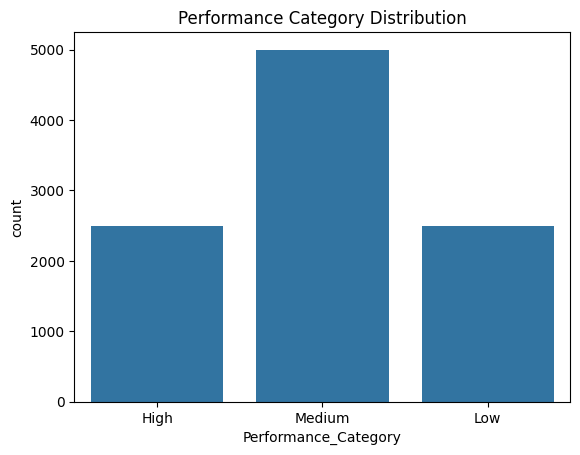

In [20]:
print(df['Performance_Category'].value_counts())
sns.countplot(data=df, x='Performance_Category', order=['High', 'Medium', 'Low'])
plt.title('Performance Category Distribution')
plt.show()

## 5. Correlation Analysis
Let's see which numeric features correlate most strongly with the `Productivity_Score`.

Productivity_Score                  1.000000
Sleep_Hours_Per_Night               0.335978
Motivation_Level                    0.301045
Assignments_Completed               0.299880
Attendance_Percentage               0.293531
Previous_Semester_GPA               0.249224
Class_Participation_Score           0.245476
Study_Hours_Per_Day                 0.167023
Physical_Activity_Hours_Per_Week    0.158180
Extracurricular_Involvement         0.092130
Age                                 0.018209
AI_Tool_Usage_Hours_Per_Week       -0.003766
Student_ID                         -0.013841
Social_Media_Hours                 -0.117656
Stress_Level                       -0.212553
Screen_Time_Hours                  -0.223059
Name: Productivity_Score, dtype: float64


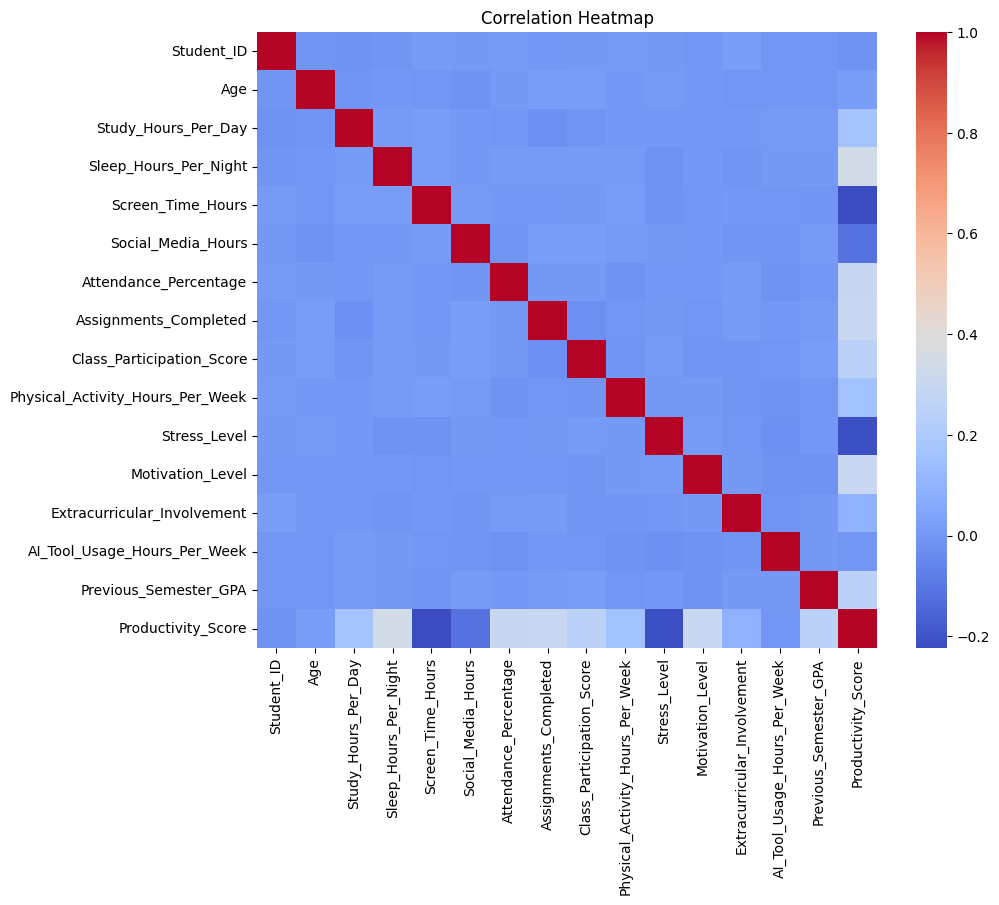

In [21]:
numeric_cols = df.select_dtypes(include=['number']).columns
correlations = df[numeric_cols].corr()['Productivity_Score'].sort_values(ascending=False)
print(correlations)

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()